# Swissgrid 2025 pandapower example

This notebook demonstrates the basic workflow for the converted Swissgrid 2025 case:

1. load the pandapower case builder and map-plotting functions;
2. plot the system on a Swiss map;
3. run a power flow;
4. plot line loading and bus-voltage magnitudes.

The notebook assumes the following folder structure:

```text
PROPER/data/powersystems/Swiss2025/
    case_swissgrid2025.py
    swissgrid2025_ppc.pkl
    metadata.json
    plot_swissgrid2025_map.py
    network_csvs/
        bus.csv
        branch.csv
        busName.csv
        gen.csv
```

In [6]:
# Optional dependencies if not already installed:
# !pip install pandapower matplotlib pandas numpy cartopy shapely

from pathlib import Path
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandapower as pp

## 1. Configure paths

Adjust `SYSTEM_DIR` only if your repository is located elsewhere.

In [8]:
DATA_DIR = "../data/powersystems/Swiss2025"
CSV_DIR = DATA_DIR + "network_csvs"
CASE_PATH = DATA_DIR + "case_swissgrid2025.py"
PLOT_SCRIPT_PATH = "../visualization/plot_swissgrid2025_map.py"

OUTPUT_DIR = "../outputs/swisscase2025/figures"
OUTPUT_DIR = Path(OUTPUT_DIR)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

assert CASE_PATH.exists(), f"Missing case file: {CASE_PATH}"
assert PLOT_SCRIPT_PATH.exists(), f"Missing plotting script: {PLOT_SCRIPT_PATH}"
assert CSV_DIR.exists(), f"Missing CSV folder: {CSV_DIR}"


AttributeError: 'str' object has no attribute 'exists'

## 2. Import local functions and load the system

In [13]:
from data.powersystems.Swiss2025.case_swissgrid2025 import case_swissgrid2025
from visualization.plot_swissgrid2025_map import (plot_line_loading_map, plot_swissgrid2025_map, plot_voltage_magnitude_map)

net = case_swissgrid2025()

print(net)
print(f"Buses: {len(net.bus)}")
print(f"Lines: {len(net.line)}")
print(f"Transformers: {len(net.trafo) if hasattr(net, 'trafo') else 0}")
print(f"Generators: {len(net.gen) if hasattr(net, 'gen') else 0}")
print(f"Static generators: {len(net.sgen) if hasattr(net, 'sgen') else 0}")
print(f"Loads: {len(net.load) if hasattr(net, 'load') else 0}")

C:\Users\roberto.rocchetta\Documents\GitHub\PROPER\.venv\Lib\site-packages\pandapower\converter\pypower\from_ppc.py:337: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  branch_lookup.loc[is_trafo, "element"] = idx_trafo


This pandapower network includes the following parameter tables:
   - bus (244 elements)
   - load (66 elements)
   - sgen (139 elements)
   - gen (62 elements)
   - ext_grid (1 element)
   - line (311 elements)
   - impedance (44 elements)
   - poly_cost (182 elements)
   - bus_geodata (244 elements)
Buses: 244
Lines: 311
Transformers: 0
Generators: 62
Static generators: 139
Loads: 66


In [14]:
#pump the demand
C = 1.2
net.load['p_mw'] = C * net.load['p_mw']


## 3. Plot the network topology on the Swiss map

This uses the previously prepared `plot_swissgrid2025_map.py`. No local Swiss shapefile is required; Cartopy/Natural Earth is used if available.

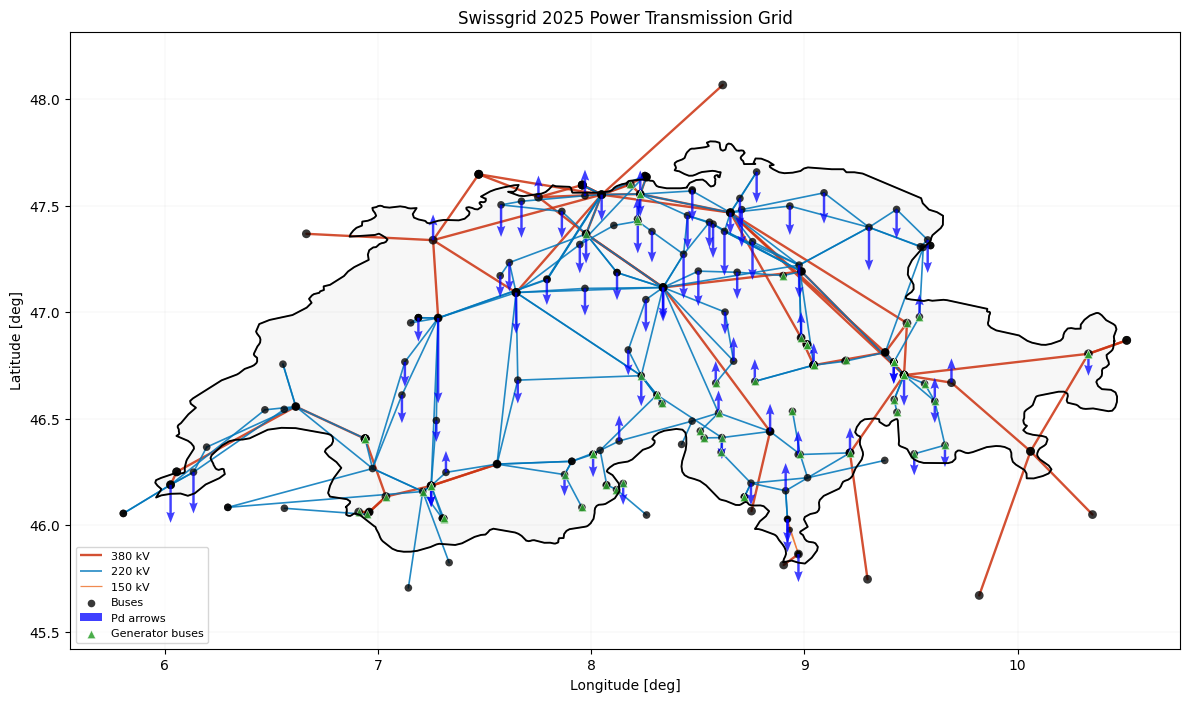

In [15]:
fig, ax = plot_swissgrid2025_map(
    network_csv_dir=CSV_DIR,
    case_py_path=CASE_PATH,
    save_path=OUTPUT_DIR / "swissgrid2025_network_map.png",
    show_swiss_map=True,
    show_swiss_boundary_on_top=True,
    show_bus_labels=False,
)
plt.show()

## 4. Run power flow

The notebook first tries an AC Newton-Raphson power flow. If this fails, it attempts a DC power flow as a diagnostic fallback. For production studies, the AC-convergence issue should be investigated rather than silently accepting the DC fallback.

In [16]:
def run_power_flow_with_fallback(net):
    """Run AC power flow; fall back to DC only for diagnostics."""
    try:
        pp.runpp(
            net,
            algorithm="nr",
            init="auto",
            calculate_voltage_angles=True,
            enforce_q_lims=False,
            numba=False,
            max_iteration=50,
            tolerance_mva=1e-6,
        )
        return "AC", None
    except Exception as ac_error:
        warnings.warn(f"AC power flow failed. Trying DC fallback. Original error: {ac_error}")
        try:
            pp.rundcpp(net, calculate_voltage_angles=True)
            return "DC", ac_error
        except Exception as dc_error:
            raise RuntimeError(
                "Both AC and DC power flow failed.\n"
                f"AC error: {ac_error}\n"
                f"DC error: {dc_error}"
            ) from dc_error

pf_mode, ac_error = run_power_flow_with_fallback(net)
print(f"Power-flow mode used: {pf_mode}")
print(f"Converged flag: {getattr(net, 'converged', None)}")
if ac_error is not None:
    print("AC error retained for diagnostics:")
    print(ac_error)

Power-flow mode used: AC
Converged flag: True


## 5. Inspect line loading and voltage results

In [17]:
def get_line_result_table(net, top_n=20):
    if len(net.line) == 0:
        return pd.DataFrame()

    res = net.res_line.copy()
    out = net.line[["from_bus", "to_bus"]].copy()
    if "name" in net.line.columns:
        out["line_name"] = net.line["name"].astype(str)
    out = pd.concat([out, res], axis=1)

    if "loading_percent" in out.columns:
        out = out.sort_values("loading_percent", ascending=False)
    elif "p_from_mw" in out.columns:
        out["abs_p_from_mw"] = out["p_from_mw"].abs()
        out = out.sort_values("abs_p_from_mw", ascending=False)

    return out.head(top_n)

line_table = get_line_result_table(net, top_n=20)
line_table

,from_bus,to_bus,line_name,p_from_mw,q_from_mvar,p_to_mw,q_to_mvar,pl_mw,ql_mvar,i_from_ka,i_to_ka,i_ka,vm_from_pu,va_from_degree,vm_to_pu,va_to_degree,loading_percent
38,13,69,,-2211.193082,190.858665,2218.686998,-90.548226,7.493916,100.310439,3.373143,3.373752,3.373752,0.999677,-2.759204,1.000000,0.000000,87.768140
159,69,72,,1950.836280,-97.733144,-1942.673331,206.983247,8.162949,109.250103,2.967706,2.966649,2.967706,1.000000,0.000000,1.000554,-3.474422,81.386786
288,185,22,,-647.631135,66.881792,647.909706,-8.259056,0.278570,58.622736,0.982898,0.982898,0.982898,1.006418,-12.038096,1.001606,-6.872303,64.692320
284,181,12,,464.731102,51.769661,-464.138902,23.057095,0.592200,74.826755,1.219551,1.219551,1.219551,1.006228,2.891990,1.000000,-6.308335,58.088907
286,183,16,,-224.367487,19.932536,224.410518,-6.845893,0.043031,13.086643,0.339858,0.339858,0.339858,1.006990,-11.806222,1.003698,-8.476791,55.921906
285,182,16,,-223.502100,19.885735,223.553649,-6.910618,0.051549,12.975117,0.338565,0.338565,0.338565,1.006950,-11.790606,1.003698,-8.476791,55.709074
298,195,88,,407.429309,-32.120435,-407.298491,50.621732,0.130818,18.501297,1.065675,1.065675,1.065675,1.006444,-10.260853,1.010726,-12.837924,50.753252
292,189,52,,498.519473,-71.884850,-498.402987,65.826746,0.116486,-6.058104,1.312779,1.312779,1.312779,1.006876,-10.221843,1.004988,-9.540354,50.023614
293,190,70,,347.242997,-7.261388,-346.953826,49.291752,0.289171,42.030364,0.914447,0.914447,0.914447,0.996751,-0.382161,1.005701,-7.270095,43.556389
129,53,72,,-1007.355038,98.891539,1012.083885,-57.095730,4.728847,41.795809,1.537875,1.539295,1.539295,1.000000,-6.536677,1.000554,-3.474422,42.213829


In [18]:
voltage_table = net.res_bus.copy()
voltage_table = pd.concat([net.bus[["name", "vn_kv"]], voltage_table], axis=1)
voltage_extremes = pd.concat([
    voltage_table.sort_values("vm_pu", ascending=True).head(10).assign(group="lowest voltage"),
    voltage_table.sort_values("vm_pu", ascending=False).head(10).assign(group="highest voltage"),
])
voltage_extremes

,name,vn_kv,vm_pu,va_degree,p_mw,q_mvar,group
113,SSILS__3,220.0,0.993863,-9.672226,0.0000,0.000,lowest voltage
176,SALBUL_3,220.0,0.993863,-9.673450,0.0000,0.000,lowest voltage
175,SALBUL_2,220.0,0.993863,-9.674541,0.0000,0.000,lowest voltage
14,SBOTTE,220.0,0.994658,-14.218322,55.7880,67.888,lowest voltage
139,SWINKE,220.0,0.995329,-12.721229,180.3708,120.920,lowest voltage
43,SFLUME,220.0,0.996142,-10.966771,62.6172,115.838,lowest voltage
49,SGERLA,220.0,0.996199,-10.968754,0.3432,-0.439,lowest voltage
90,SMONTL,220.0,0.996324,-12.869300,96.5040,-4.919,lowest voltage
84,SMOERS,220.0,0.996350,-13.033939,64.2804,-11.723,lowest voltage
196,SROMAN2T,220.0,0.996403,-14.268563,0.0000,0.000,lowest voltage


## 6. Plot line loading after power flow

For AC/DC `pandapower` results, the preferred quantity is `net.res_line.loading_percent`. If this column is not available, the function falls back to absolute active power flow `|p_from_mw|`.

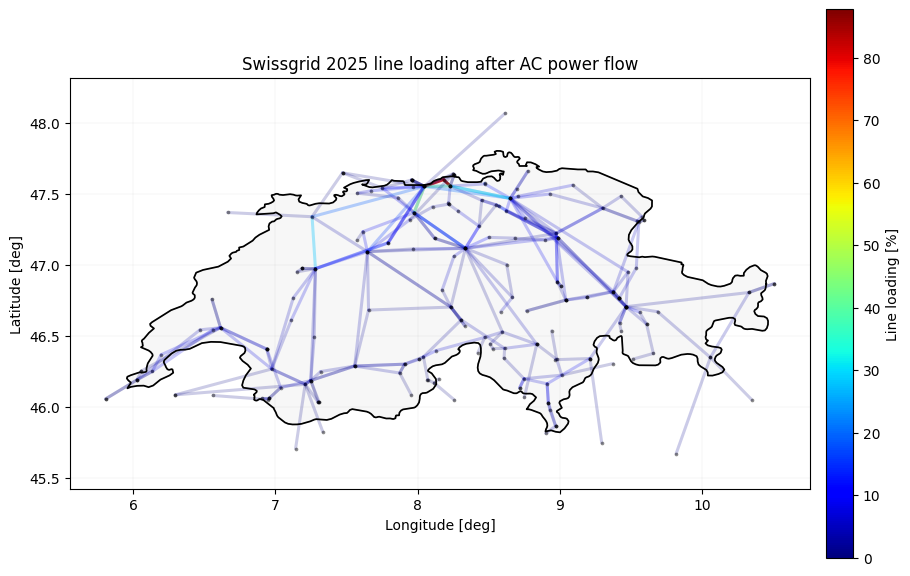

In [19]:
fig, ax = plot_line_loading_map(
    net,
    save_path=OUTPUT_DIR / "swissgrid2025_line_loading_map.png",
    min_alpha=0.2,
    max_alpha=1.0,
    alpha_reference=99.0,
    alpha_power=1.4,
)
plt.show()

## 7. Plot voltage magnitudes after power flow

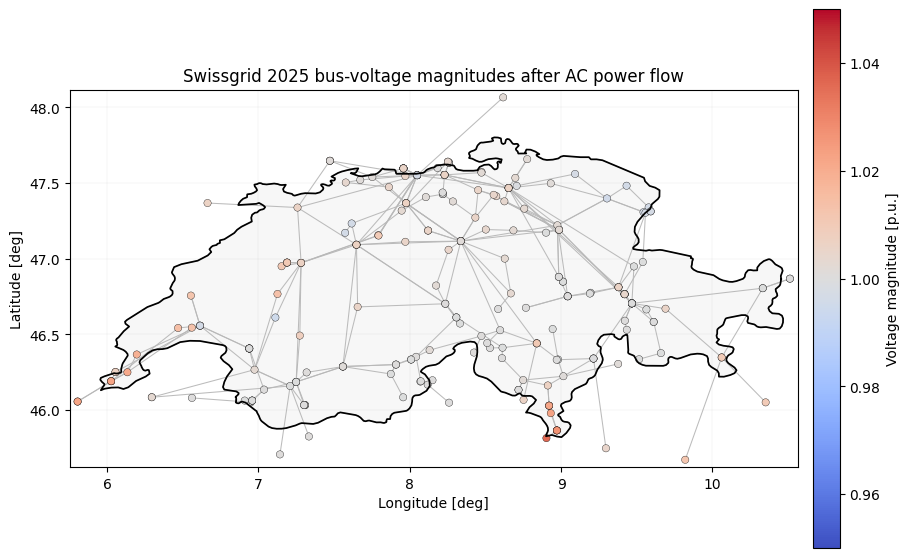

In [20]:
fig, ax = plot_voltage_magnitude_map(
    net,
    save_path=OUTPUT_DIR / "swissgrid2025_voltage_magnitude_map.png",
    margin_deg=0.05,
)
plt.show()


## 8 . Save selected numerical outputs

In [21]:
line_results_path = OUTPUT_DIR / "swissgrid2025_line_results.csv"
bus_results_path = OUTPUT_DIR / "swissgrid2025_bus_voltage_results.csv"

line_results = pd.concat([net.line, net.res_line], axis=1)
bus_results = pd.concat([net.bus, net.res_bus], axis=1)

line_results.to_csv(line_results_path, index=True)
bus_results.to_csv(bus_results_path, index=True)

print(f"Saved line results to: {line_results_path}")
print(f"Saved bus voltage results to: {bus_results_path}")

Saved line results to: C:\Users\roberto.rocchetta\Documents\GitHub\PROPER\output\swisscase2025\figures\swissgrid2025_line_results.csv
Saved bus voltage results to: C:\Users\roberto.rocchetta\Documents\GitHub\PROPER\output\swisscase2025\figures\swissgrid2025_bus_voltage_results.csv
